# Contents

1. Missing Value Analysis
2. Duplicate Analysis
3. Data Type Validation
4. Invalid Category Analysis
5. Whitespace Check
6. Outlier Analysis
7. Cardinality Analysis
8. Data Consistency Analysis
9. Data Leakage Analysis
10. Summary

## Section 1 — Import Libraries

In [81]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Section 2 — Load Dataset

In [82]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Section 3 — Basic Information

In [83]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [84]:
df.shape

(7043, 21)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [86]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Section 4 — Missing Value Analysis

In [87]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [88]:
(df.apply(lambda col: col.astype(str).str.strip() == "")).sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [89]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [90]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Section 5 — Duplicate Analysis


In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df["customerID"].duplicated().sum()

np.int64(0)

This section answers one question:

Are there repeated records or repeated customers?

## Section 6 — Data Type Validation

In [93]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [94]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Section 7 — Invalid Categories
The goal here is to verify that every categorical column contains only expected business values.

In [96]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(col)
    print(df[col].unique())

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']


## Section 8 — Whitespace Check
This confirms there are no hidden leading or trailing spaces that could create duplicate categories.

In [97]:
for col in categorical_columns:
    print(df[col].str.strip().equals(df[col]))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


## Section 9 — Outlier Analysis

## Outlier Analysis

### Objective
Outliers are observations that significantly differ from the majority of the data.
They may arise due to:
- Data entry errors
- Measurement errors
- Genuine but rare observations

Detecting outliers is important because some machine learning algorithms are sensitive
to extreme values.

For this dataset, we will use the **Interquartile Range (IQR)** method to identify
potential outliers in the numerical features.

The numerical columns are:
- tenure
- MonthlyCharges
- TotalCharges

In [98]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
['tenure', 'MonthlyCharges', 'TotalCharges']


### Step 2 — Detect Outliers Using IQR

In [99]:
# Detect potential outliers using the IQR method

outlier_summary = []

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,tenure,9.00,55.00,46.00,-60.00,124.00,0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0


In [100]:
outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,tenure,9.00,55.00,46.00,-60.00,124.00,0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0


### Step 3 — Visual Verification Using Boxplots

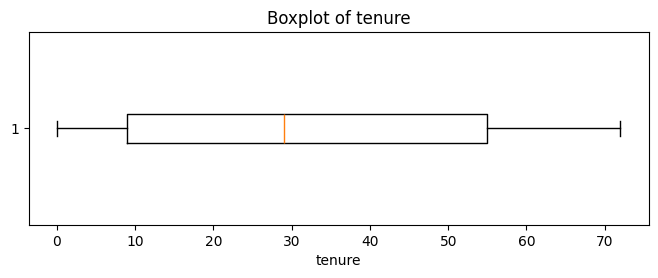

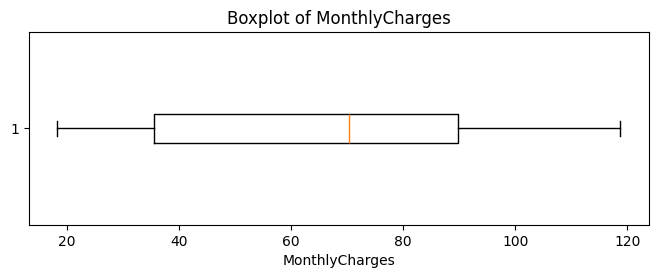

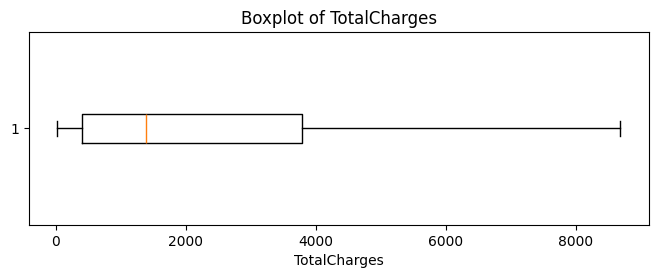

In [101]:
import matplotlib.pyplot as plt

for col in numerical_columns:

    plt.figure(figsize=(8, 2.5))

    plt.boxplot(df[col].dropna(), vert=False)

    plt.title(f"Boxplot of {col}")

    plt.xlabel(col)

    plt.show()

### Step 4 — Inspect Outlier Records (Optional but Professional)

In [102]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print("=" * 60)
    print(f"{col}")
    print(f"Number of Outliers : {len(outliers)}")

    display(outliers.head())

tenure
Number of Outliers : 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


MonthlyCharges
Number of Outliers : 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


TotalCharges
Number of Outliers : 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


## Section 10 — Cardinality Analysis


## Cardinality Analysis

### Objective

Cardinality refers to the number of unique values present in a feature.

Understanding the cardinality of categorical variables helps us:

- Identify identifier columns
- Select appropriate encoding techniques
- Detect features with unusually high unique values
- Understand the complexity of categorical data

For this dataset, we will calculate the number of unique values in every feature.

### Step 1 — Calculate Cardinality


In [103]:
# Calculate the number of unique values for each feature

cardinality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique()
})

cardinality = cardinality.sort_values(
    by="Unique Values",
    ascending=False
)

cardinality

,Data Type,Unique Values
customerID,object,7043
TotalCharges,float64,6530
MonthlyCharges,float64,1585
tenure,int64,73
PaymentMethod,object,4
StreamingMovies,object,3
TechSupport,object,3
OnlineBackup,object,3
StreamingTV,object,3
DeviceProtection,object,3


### Step 2 — Separate Categorical Features


In [104]:
# Display unique values only for categorical features

categorical_cardinality = pd.DataFrame({
    "Unique Values": df.select_dtypes(include="object").nunique()
}).sort_values(
    by="Unique Values",
    ascending=False
)

categorical_cardinality

,Unique Values
customerID,7043
PaymentMethod,4
OnlineBackup,3
InternetService,3
OnlineSecurity,3
TechSupport,3
StreamingTV,3
DeviceProtection,3
MultipleLines,3
StreamingMovies,3


### Step 3 — Identify High Cardinality Features

In [105]:
# Identify features with more than 50 unique values

high_cardinality = cardinality[
    cardinality["Unique Values"] > 50
]

high_cardinality

,Data Type,Unique Values
customerID,object,7043
TotalCharges,float64,6530
MonthlyCharges,float64,1585
tenure,int64,73


Important: Although tenure, MonthlyCharges, and TotalCharges appear because they have more than 50 unique values, they are numerical variables, not high-cardinality categorical variables. The only true high-cardinality categorical feature is customerID, which is simply an identifier.

### Observation

- Most categorical features have very low cardinality (2–4 unique values).
- `customerID` has a unique value for every record and functions as an identifier.
- Numerical features naturally have many distinct values and are not considered high-cardinality categorical variables.

### Business Insight

The dataset is well-suited for machine learning because nearly all categorical variables have low cardinality, making them straightforward to encode.

The `customerID` column does not contain predictive information and will be removed during preprocessing before model training.

### Interview Tip

If an interviewer asks:

### "Why did you perform cardinality analysis?"

A strong answer is:

"I performed cardinality analysis to understand the uniqueness of each feature, identify identifier columns like customerID, and choose appropriate encoding strategies. Since all business-related categorical variables had low cardinality (2–4 categories), One-Hot Encoding is suitable. The only high-cardinality categorical feature was customerID, which was excluded because it doesn't carry predictive information."

This demonstrates not just what you did, but why you did it.

## Section 11 – Data Consistency Analysis

### Data Consistency Analysis

### Objective

Data consistency checks verify that related features follow logical business rules.

Even if a dataset has no missing values or duplicates, inconsistent relationships between columns can introduce errors into downstream analysis and machine learning models.

For this dataset, we validate:

1. PhoneService ↔ MultipleLines
2. InternetService ↔ Internet-related services

### Rule 1 — Phone Service Consistency

In [106]:
# Customers without phone service

phone_service_check = df[df["PhoneService"] == "No"][
    ["PhoneService", "MultipleLines"]
]

phone_service_check.head()

,PhoneService,MultipleLines
0,No,No phone service
3,No,No phone service
7,No,No phone service
20,No,No phone service
27,No,No phone service


In [107]:
# Count inconsistent records

invalid_phone_records = phone_service_check[
    phone_service_check["MultipleLines"] != "No phone service"
]

print("Invalid Phone Records:", len(invalid_phone_records))

Invalid Phone Records: 0


### Rule 2 — Internet Service Consistency


In [108]:
internet_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

internet_service_check = df[df["InternetService"] == "No"][
    internet_columns
]

internet_service_check.head()

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
11,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
16,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
21,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
22,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
33,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service


In [109]:
# Check for inconsistencies

invalid_internet_records = df[
    (df["InternetService"] == "No") &
    (
        (df["OnlineSecurity"] != "No internet service") |
        (df["OnlineBackup"] != "No internet service") |
        (df["DeviceProtection"] != "No internet service") |
        (df["TechSupport"] != "No internet service") |
        (df["StreamingTV"] != "No internet service") |
        (df["StreamingMovies"] != "No internet service")
    )
]

print("Invalid Internet Records:", len(invalid_internet_records))

Invalid Internet Records: 0


### Observation

- All customers without phone service correctly have `MultipleLines = "No phone service"`.
- All customers without internet service correctly have `"No internet service"` in all dependent internet-related features.
- No business rule violations were identified.

### Business Insight

The dataset maintains strong internal consistency across related service features.

This indicates that the data collection process followed defined business rules, reducing the likelihood of logical inconsistencies affecting downstream preprocessing or model performance.

## Section 12 – Data Leakage Analysis

## 2.9 Data Leakage Analysis

### Objective

Data leakage occurs when a feature contains information about the target variable that would not be available during real-world prediction.

Such features can lead to unrealistically high model performance and poor generalization.

In this section, we inspect the dataset for:

- Identifier columns
- Features that directly reveal churn
- Features unavailable at prediction time

### Step 1 – Review Dataset Columns

In [110]:
# Display all feature names

print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


### Step 2 – Check Identifier Columns

In [111]:
# Check uniqueness of customerID

print("Unique customer IDs :", df["customerID"].nunique())
print("Total Records       :", len(df))

Unique customer IDs : 7043
Total Records       : 7043


### Step 3 – Verify Target Column

In [112]:
# Inspect target classes

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Step 4 – Manual Leakage Assessment

In [113]:
### Summary of leakage assessment

leakage_summary = pd.DataFrame({
    "Feature": [
        "customerID",
        "Service Features",
        "Billing Features",
        "Target Variable"
    ],
    "Assessment": [
        "Identifier (Drop before modeling)",
        "Available before prediction",
        "Available before prediction",
        "Prediction Target"
    ]
})

leakage_summary

,Feature,Assessment
0,customerID,Identifier (Drop before modeling)
1,Service Features,Available before prediction
2,Billing Features,Available before prediction
3,Target Variable,Prediction Target


### Observation

- No feature directly reveals whether a customer will churn.
- All service and billing attributes are available before making a prediction.
- `customerID` is a unique identifier and does not provide predictive information.
- No evidence of target leakage was identified.

### Business Insight

The dataset is suitable for supervised machine learning because it does not contain target leakage.

The `customerID` column will be removed during preprocessing, as it is an identifier rather than a predictive feature.

All remaining features represent information that would realistically be available when predicting customer churn.

# Data Quality Assessment Summary

The data quality assessment was completed successfully.

### Key Findings

- Converted `TotalCharges` to numeric format.
- Identified 11 missing values after conversion.
- No duplicate records or duplicate customer IDs.
- All categorical values are valid.
- No leading or trailing whitespace issues.
- No problematic outliers detected.
- Most categorical features have low cardinality.
- Business consistency rules were satisfied.
- No target leakage was identified.
- `customerID` will be removed during preprocessing.

### Conclusion

The dataset is clean, internally consistent, and suitable for exploratory data analysis and machine learning after handling the small number of missing values and removing the identifier column.

## Save Processed Dataset

After completing the data quality assessment and applying all necessary cleaning operations, the cleaned dataset is saved for use in subsequent phases of the project.

Saving the processed dataset ensures that all future analyses and machine learning tasks use the same cleaned and consistent version of the data.

This also avoids repeating the data cleaning steps in every notebook and establishes a reproducible workflow.

In [115]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

In [120]:
# df.info()
df.shape

(7032, 21)

In [121]:
# Create the processed directory (if needed)
from pathlib import Path

processed_data_path = Path("../data/processed")
processed_data_path.mkdir(parents=True, exist_ok=True)


# Save the cleaned dataset
output_file = processed_data_path / "v1_customer_churn_processed.csv"
df.to_csv(output_file, index=False)
print(f"Processed dataset saved successfully to:\n{output_file}")

# Verify
pd.read_csv(output_file).head()

Processed dataset saved successfully to:
..\data\processed\v1_customer_churn_processed.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
